### __Task 2 (50 points)__: In this task, you will pick a dataset (time-series or any other form of sequential data) and an associated problem that can be solved via sequence models. You must describe why you need sequence models to solve this problem. Include a link to the dataset source. Next, you should pick an RNN framework that you would use to solve this problem (This framework can be in TensorFlow, PyTorch or any other Python Package)

#### Dataset Link: https://finance.yahoo.com/quote/TSM/history/
* I'm importing through the yahoo finance python library, so I'm not sure where to exactly link to but, I'll put the Yahoo Finance Page for reference
* I chose TSMC bc I have some shares, and it has been doing well, so I have an interest in it

### Part 1
Implement your RNN either using an existing framework OR you can implement your own RNN cell structure. In either case, describe the structure of your RNN and the activation functions you are using for each time step and in the output layer. Define a metric you will use to measure the performance of your model

In [36]:
import yfinance as yf

tsmc = yf.Ticker("TSM")
data = tsmc.history(start="2010-01-01", end="2024-01-01")

print(data.head())

                               Open      High       Low     Close    Volume  \
Date                                                                          
2010-01-04 00:00:00-05:00  7.199770  7.325093  7.187238  7.256166   8096400   
2010-01-05 00:00:00-05:00  7.268698  7.306294  7.180972  7.224834  14375900   
2010-01-06 00:00:00-05:00  7.243632  7.274962  7.130841  7.199769  13608400   
2010-01-07 00:00:00-05:00  7.149642  7.168440  6.936594  6.961658  27346600   
2010-01-08 00:00:00-05:00  6.980458  7.030587  6.911530  6.955393  16895300   

                           Dividends  Stock Splits  
Date                                                
2010-01-04 00:00:00-05:00        0.0           0.0  
2010-01-05 00:00:00-05:00        0.0           0.0  
2010-01-06 00:00:00-05:00        0.0           0.0  
2010-01-07 00:00:00-05:00        0.0           0.0  
2010-01-08 00:00:00-05:00        0.0           0.0  


### Data-visualization
#### Closing price over time

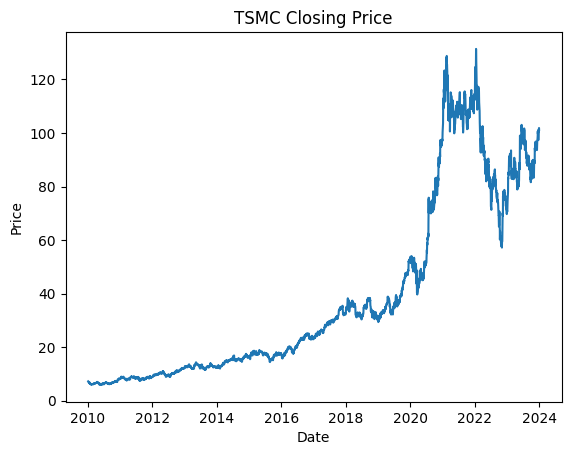

In [37]:
import matplotlib.pyplot as plt

plt.plot(data['Close'])
plt.title("TSMC Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

#### I will be using the closing price as my target

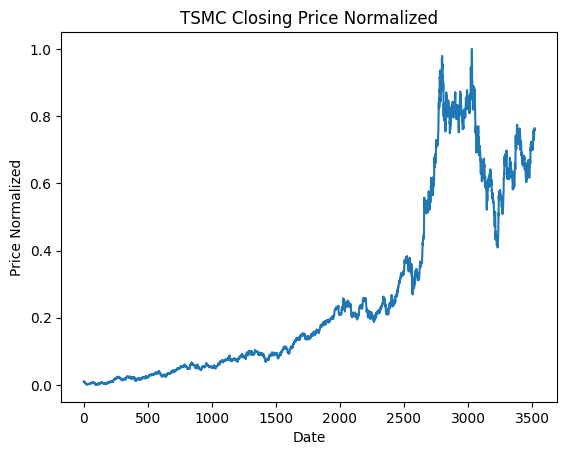

In [38]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

closing_history = data[['Close']]

scaler = MinMaxScaler()

normalized_close = scaler.fit_transform(closing_history)

plt.plot(normalized_close)
plt.title("TSMC Closing Price Normalized")
plt.xlabel("Date")
plt.ylabel("Price Normalized")
plt.show()


#### Data Makeup
I will be using a window of 30 days and using it to predict the next days closing price

I will perform a train/val/test split by taking the test set as the future data past a specific point

In [39]:
def create_sequences(data, window_size):
    X = []
    y = []

    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])

    return np.array(X), np.array(y)

In [40]:
window_size = 30

X, y = create_sequences(normalized_close, window_size)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3492, 30, 1)
y shape: (3492, 1)


In [41]:
# 80/10/10 split
train_size = int(len(X) * 0.8)
val_size = int(len(X) * 0.10)

X_train = X[:train_size]
X_val = X[train_size:train_size+val_size]
X_test = X[train_size+val_size:]

y_train = y[:train_size]
y_val = y[train_size:train_size+val_size]
y_test = y[train_size+val_size:]

In [42]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

#dont shuffle the time series data
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=False)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=32, shuffle=False)

In [43]:
import torch.nn as nn

class SimpleRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2):
        super(SimpleRNN, self).__init__()

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity='tanh'
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

### Describe the structure of your RNN and the activation functions you are using for each time step and in the output layer

Activations:
* Using tanh activation for the hidden layers
* Using linear for the output because the target is regression

Performance Metric:
* I'm going to use MSE as we are doing regression, and it measures the average squared difference between the observed values and the values predicted by the model

In [44]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleRNN()
model = model.to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [45]:
num_epochs = 50
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval() #validation set
    val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch: {epoch+1}, Train Loss: {train_loss:1.4f}, Val Loss: {val_loss:1.4f}")

Epoch: 1, Train Loss: 0.0027, Val Loss: 0.0316
Epoch: 2, Train Loss: 0.0391, Val Loss: 0.0084
Epoch: 3, Train Loss: 0.0348, Val Loss: 0.0141
Epoch: 4, Train Loss: 0.0391, Val Loss: 0.0088
Epoch: 5, Train Loss: 0.0479, Val Loss: 0.2397
Epoch: 6, Train Loss: 0.0324, Val Loss: 0.2254
Epoch: 7, Train Loss: 0.0207, Val Loss: 0.1050
Epoch: 8, Train Loss: 0.0082, Val Loss: 0.0033
Epoch: 9, Train Loss: 0.0022, Val Loss: 0.0027
Epoch: 10, Train Loss: 0.0007, Val Loss: 0.0007
Epoch: 11, Train Loss: 0.0003, Val Loss: 0.0011
Epoch: 12, Train Loss: 0.0006, Val Loss: 0.0008
Epoch: 13, Train Loss: 0.0008, Val Loss: 0.0015
Epoch: 14, Train Loss: 0.0023, Val Loss: 0.0013
Epoch: 15, Train Loss: 0.0017, Val Loss: 0.0031
Epoch: 16, Train Loss: 0.0037, Val Loss: 0.0075
Epoch: 17, Train Loss: 0.0026, Val Loss: 0.0050
Epoch: 18, Train Loss: 0.0042, Val Loss: 0.0181
Epoch: 19, Train Loss: 0.0032, Val Loss: 0.0013
Epoch: 20, Train Loss: 0.0023, Val Loss: 0.0093
Epoch: 21, Train Loss: 0.0024, Val Loss: 0.0021
E

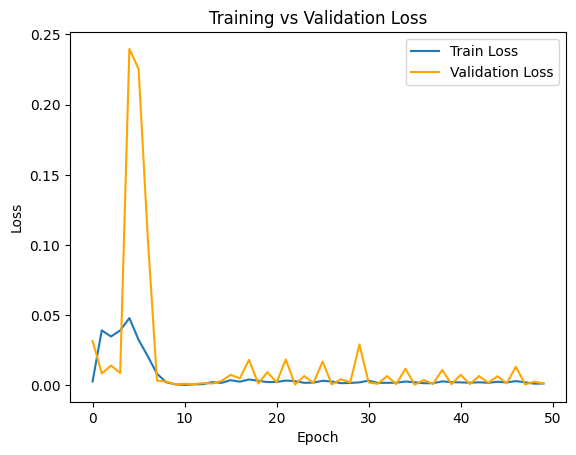

In [46]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss", color='orange')
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [47]:
model.eval() #test set
with torch.no_grad():
    RNN_val_predictions = model(X_val)
    RNN_test_predictions = model(X_test)
    val_loss = criterion(RNN_val_predictions, y_val)
    test_loss = criterion(RNN_test_predictions, y_test)

print("Val Error (MSE):", val_loss.item())
print("Test Error (MSE):", test_loss.item())

Val Error (MSE): 0.0012425152817741036
Test Error (MSE): 0.002270463155582547


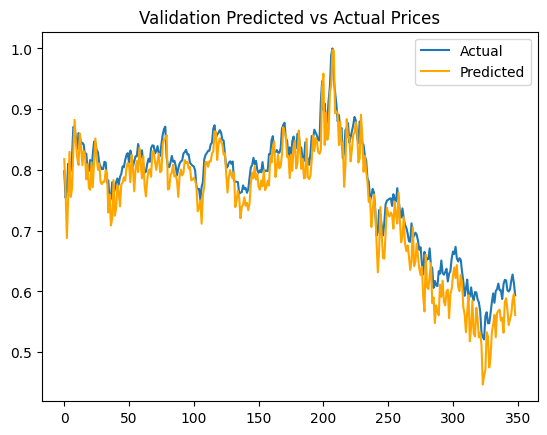

In [48]:
plt.plot(y_val.numpy(), label="Actual")
plt.plot(RNN_val_predictions.numpy(), label="Predicted", color='orange')
plt.legend()
plt.title("Validation Predicted vs Actual Prices")
plt.show()

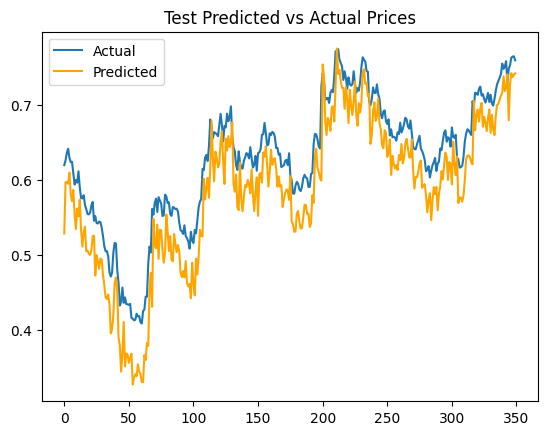

In [49]:
plt.plot(y_test.numpy(), label="Actual")
plt.plot(RNN_test_predictions.numpy(), label="Predicted", color='orange')
plt.legend()
plt.title("Test Predicted vs Actual Prices")
plt.show()

I think it does pretty good, but can be better.

### Part 2
#### Update your network from part 1 with first an LSTM and then a GRU based cell structure (You can treat both as 2 separate implementations). Re-do the training and performance evaluation. What are the major differences you notice? Why do you think those differences exist between the 3 implementations (basic RNN, LSTM and GRU)?

In [50]:
class SimpleLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2):
        super(SimpleLSTM, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

In [51]:
class SimpleGRU(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2):
        super(SimpleGRU, self).__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

### Describe the structure of your LSTM & GRU and the activation functions you are using for each time step and in the output layer

#### LSTM
Activations:
* Using tanh and sigmoid for the internal gates
* Using linear for the output because the target is regression just like the RNN

Performance Metric:
* MSE same as before

#### GRU
Activations:
* Similar to LSTM model, but it is slightly simplified by combining the input and forget gates
* Using linear for the output same as before

Performance Metric:
* MSE same as before

In [52]:
model = SimpleLSTM()
model = model.to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 50
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()  #validation set
    val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch: {epoch + 1}, Train Loss: {train_loss:1.4f}, Val Loss: {val_loss:1.4f}")

Epoch: 1, Train Loss: 0.0023, Val Loss: 0.0475
Epoch: 2, Train Loss: 0.0615, Val Loss: 0.2846
Epoch: 3, Train Loss: 0.0324, Val Loss: 0.2409
Epoch: 4, Train Loss: 0.0239, Val Loss: 0.0759
Epoch: 5, Train Loss: 0.0109, Val Loss: 0.0265
Epoch: 6, Train Loss: 0.0067, Val Loss: 0.0078
Epoch: 7, Train Loss: 0.0067, Val Loss: 0.0383
Epoch: 8, Train Loss: 0.0074, Val Loss: 0.0262
Epoch: 9, Train Loss: 0.0084, Val Loss: 0.0141
Epoch: 10, Train Loss: 0.0089, Val Loss: 0.0643
Epoch: 11, Train Loss: 0.0084, Val Loss: 0.0008
Epoch: 12, Train Loss: 0.0020, Val Loss: 0.0008
Epoch: 13, Train Loss: 0.0014, Val Loss: 0.0014
Epoch: 14, Train Loss: 0.0033, Val Loss: 0.0020
Epoch: 15, Train Loss: 0.0026, Val Loss: 0.0076
Epoch: 16, Train Loss: 0.0048, Val Loss: 0.0011
Epoch: 17, Train Loss: 0.0019, Val Loss: 0.0039
Epoch: 18, Train Loss: 0.0040, Val Loss: 0.0015
Epoch: 19, Train Loss: 0.0022, Val Loss: 0.0048
Epoch: 20, Train Loss: 0.0043, Val Loss: 0.0018
Epoch: 21, Train Loss: 0.0021, Val Loss: 0.0042
E

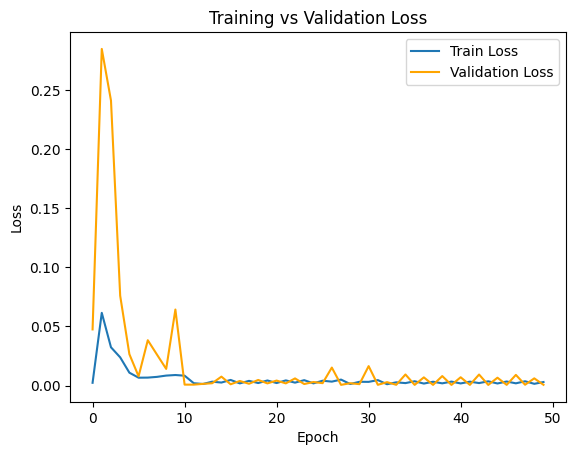

In [53]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss", color='orange')
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [54]:
model.eval() #test set
with torch.no_grad():
    LSTM_val_predictions = model(X_val)
    LSTM_test_predictions = model(X_test)
    val_loss = criterion(LSTM_val_predictions, y_val)
    test_loss = criterion(LSTM_test_predictions, y_test)

print("Val Error (MSE):", val_loss.item())
print("Test Error (MSE):", test_loss.item())

Val Error (MSE): 0.0006550892721861601
Test Error (MSE): 0.0005340456264093518


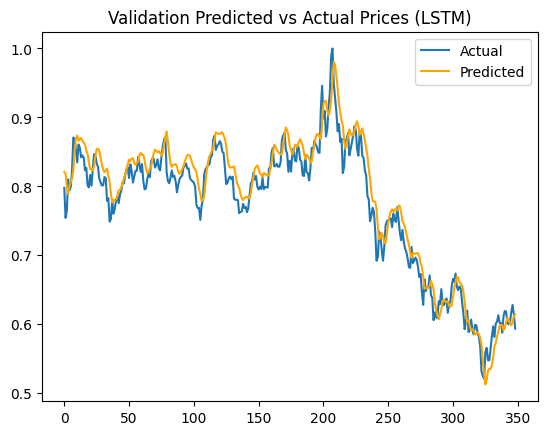

In [55]:
plt.plot(y_val.numpy(), label="Actual")
plt.plot(LSTM_val_predictions.numpy(), label="Predicted", color='orange')
plt.legend()
plt.title("Validation Predicted vs Actual Prices (LSTM)")
plt.show()

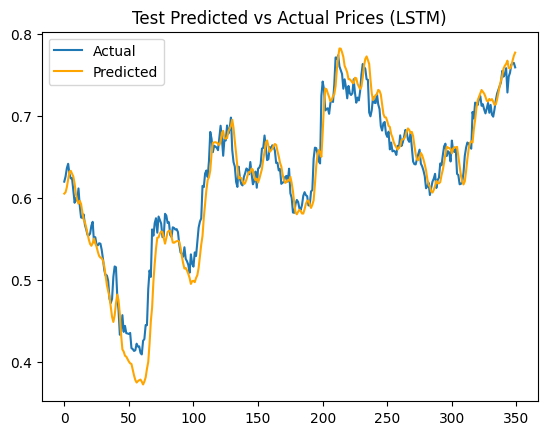

In [56]:
plt.plot(y_test.numpy(), label="Actual")
plt.plot(LSTM_test_predictions.numpy(), label="Predicted", color='orange')
plt.legend()
plt.title("Test Predicted vs Actual Prices (LSTM)")
plt.show()

In [57]:
model = SimpleGRU()
model = model.to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 50
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()  #validation set
    val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch: {epoch + 1}, Train Loss: {train_loss:1.4f}, Val Loss: {val_loss:1.4f}")

Epoch: 1, Train Loss: 0.0023, Val Loss: 0.0287
Epoch: 2, Train Loss: 0.0412, Val Loss: 0.0729
Epoch: 3, Train Loss: 0.0172, Val Loss: 0.0159
Epoch: 4, Train Loss: 0.0042, Val Loss: 0.0033
Epoch: 5, Train Loss: 0.0025, Val Loss: 0.0062
Epoch: 6, Train Loss: 0.0032, Val Loss: 0.0024
Epoch: 7, Train Loss: 0.0031, Val Loss: 0.0106
Epoch: 8, Train Loss: 0.0034, Val Loss: 0.0009
Epoch: 9, Train Loss: 0.0020, Val Loss: 0.0048
Epoch: 10, Train Loss: 0.0025, Val Loss: 0.0010
Epoch: 11, Train Loss: 0.0025, Val Loss: 0.0076
Epoch: 12, Train Loss: 0.0029, Val Loss: 0.0007
Epoch: 13, Train Loss: 0.0020, Val Loss: 0.0046
Epoch: 14, Train Loss: 0.0024, Val Loss: 0.0008
Epoch: 15, Train Loss: 0.0023, Val Loss: 0.0059
Epoch: 16, Train Loss: 0.0026, Val Loss: 0.0007
Epoch: 17, Train Loss: 0.0021, Val Loss: 0.0048
Epoch: 18, Train Loss: 0.0025, Val Loss: 0.0008
Epoch: 19, Train Loss: 0.0022, Val Loss: 0.0049
Epoch: 20, Train Loss: 0.0024, Val Loss: 0.0012
Epoch: 21, Train Loss: 0.0016, Val Loss: 0.0013
E

In [58]:
model.eval()  #test set
with torch.no_grad():
    GRU_val_predictions = model(X_val)
    GRU_test_predictions = model(X_test)
    val_loss = criterion(GRU_val_predictions, y_val)
    test_loss = criterion(GRU_test_predictions, y_test)

print("Val Error (MSE):", val_loss.item())
print("Test Error (MSE):", test_loss.item())

Val Error (MSE): 0.0006634273449890316
Test Error (MSE): 0.0010851905681192875


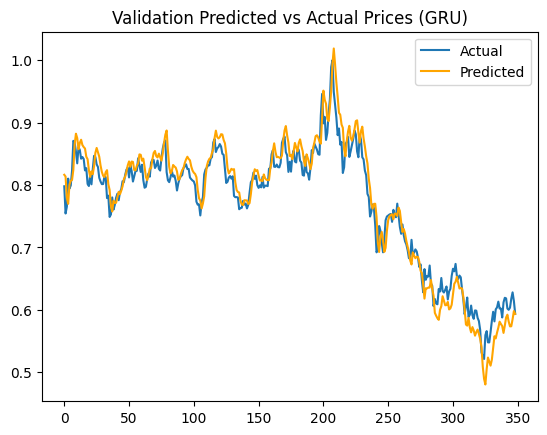

In [59]:
plt.plot(y_val.numpy(), label="Actual")
plt.plot(GRU_val_predictions.numpy(), label="Predicted", color='orange')
plt.legend()
plt.title("Validation Predicted vs Actual Prices (GRU)")
plt.show()

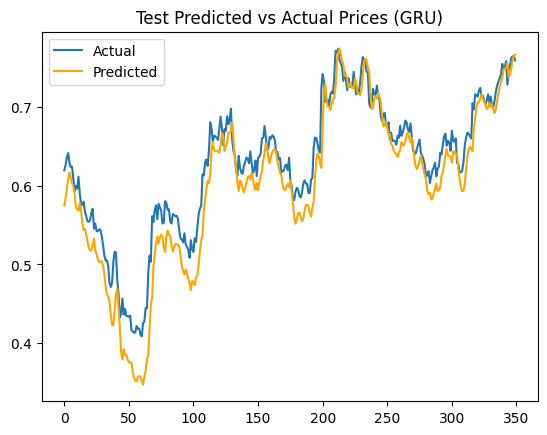

In [60]:
plt.plot(y_test.numpy(), label="Actual")
plt.plot(GRU_test_predictions.numpy(), label="Predicted", color='orange')
plt.legend()
plt.title("Test Predicted vs Actual Prices (GRU)")
plt.show()

#### Make a nice visualization of all models to compare with
_(after note: not as nice as I thought it would be, kinda cluttered)_

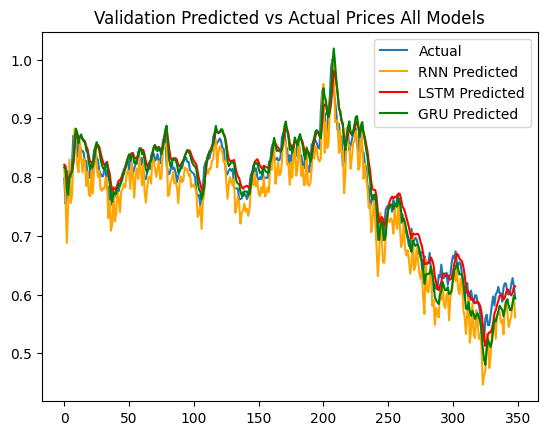

In [64]:
plt.plot(y_val.numpy(), label="Actual")
plt.plot(RNN_val_predictions.numpy(), label="RNN Predicted", color='orange')
plt.plot(LSTM_val_predictions.numpy(), label="LSTM Predicted", color='red')
plt.plot(GRU_val_predictions.numpy(), label="GRU Predicted", color='green')
plt.legend()
plt.title("Validation Predicted vs Actual Prices All Models")
plt.show()

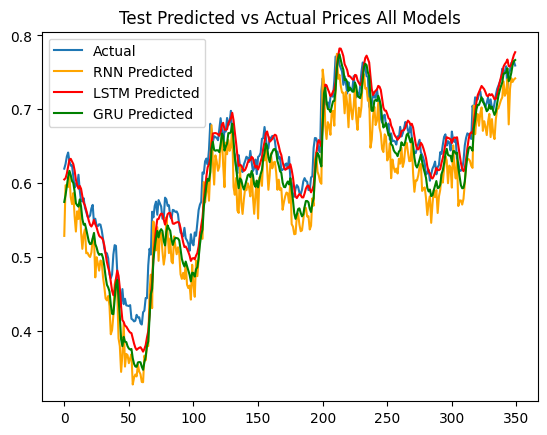

In [65]:
plt.plot(y_test.numpy(), label="Actual")
plt.plot(RNN_test_predictions.numpy(), label="RNN Predicted", color='orange')
plt.plot(LSTM_test_predictions.numpy(), label="LSTM Predicted", color='red')
plt.plot(GRU_test_predictions.numpy(), label="GRU Predicted", color='green')
plt.legend()
plt.title("Test Predicted vs Actual Prices All Models")
plt.show()

####  What are the major differences you notice? Why do you think those differences exist between the 3 implementations.
The first thing that I noticed is that the LSTM and GRU models perform better than the RNN, both visually and MSE metric wise. The metrics improved by almost double for both models compared to the RNN. Another thing I noticed is that the LSTM and GRU models took longer to train than the RNN model.

Both of these things can be explained by the model structure. Both LSTM and GRU use extra memory compared to the vanilla RNN, as they store more information to pass thorough to the next step of the model. Not only does this extra information allow for more accurate predictions as there's more information available at a single time step compared to the RNN model, it also increases training time as there's more computation and memory involved.

### Part 3
#### Can you use the traditional feed-forward network to solve the same problem. Why or why not? (Hint: Can time series data be converted to usual features that can be used as input to a feed-forward network?)

You can use a traditional feed forward NN to make these predictions. You can transform the data sequences into structured data to input into the model. For example, I used a window of 30 days, so if we transformed the data into a 30 element vector we could pass that as the input features to a model. There are several disadvantages to this approach. For one the input size is now fixed, you can only use a 30-day window, but in the case of recurrent models you can use different sized window as you just run it over more steps, however you do need to make some changes to the model, and it might not generalize to the new sequences right. Another disadvantage is that the model doesn't exactly extract the sequential relations of the data, as it only sees a flat input, especially for longer sequences. The NN might not capture the relation, while the LSTM and GRU moels have a sequential memory mechanism for each sequence that handles sequential information better. While you can do this task with a standard neural network it might not be the best choice.

### __Task 3 (50 points):__
#### Part 1: Implementing Word Embeddings
#### Use a pre-trained word embedding model (Word2Vec, GloVe, FastText, or BERT embeddings)

In [2]:
import gensim
from gensim.models import Word2Vec
from gensim.models import KeyedVectors

#location of pretrained model data
pretrained_model_path = 'GoogleNews-vectors-negative300.bin.gz'

#### Provide a comparative discussion on why you chose this embedding over others

#### Word2Vec:
__Advantages:__
* The model is relatively simple compared to other word embedding models, but it is still powerful so it has fast training and inference compared to more complex models
* It captures meaningful sematic relationships like word relationships and analogies (popular example: king - man + woman = queen)
* It is scalable and can handle larger datasets efficiently thanks to its low computational cost and simplicity

__Disadvantages:__
* Can not natively handle out of vocabulary words
* Treats words as a unit, so it loses some sub-word information, like compound words
* Fixed context window, so long range word dependencies can be lost
* Only works for a single language so multiple models needed for multiple languages

#### GloVe:
__Advantages:__
* The model utilizes global statistics, so it uses dataset wide information for better representation
* Trains fast, on average it converges faster than word2vec
* It performs consistently across many training runs
* Foundationally strong with well-defined optimization objectives making training easier

__Disadvantages:__
* Memory intensive, it stores the entire co-occurrence matrix which can be large for extensive vocabularies
* Can not natively handle out of vocabulary words
* Model performance depends on pre-processing and hyperparameter tuning

#### FastText:
__Advantages:__
* Has the ability to natively handle out of vocabulary words
* Has sub-word context awareness, so it can handle information within individual words
* Can handle multiple languages
* An extension of word2vec, keeps benefits of word2vecand adds ned capabilities
* Handles infrequent words better due to sub-word processing

__Disadvantages:__
* Increased complexity, longer training and more overhead compared to other similar models
* Certain applications are sensitive to noise
* Increased complexity means increased memory requirement for using the model
* Sensitive to hyperparameters, so correct tuning is required for optimal performance

#### BERT:
__Advantages:__
* Deep contextual understanding, leads to a more context aware representations of words
* The B stands for bidirectional, which means the model reads the sentence both forward and backward to extract more contextual information
* It handles contextual ambiguity in complex sentences

__Disadvantages:__
* Extremely resource and memory intensive
* Slow to train and ues due to model complexity
* Computational cost makes it inapplicable for simple tasks and resource-limited environments

Why I chose word2vec:
I've heard of it before, and it is the one that I am most familiar with, so I chose to use it in my implementation.

#### Load embeddings efficiently (either from pre-trained vectors or using an NLP library like Gensim, SpaCy, or Hugging Face).

In [ ]:
#load pretrained model
word_vectors = KeyedVectors.load_word2vec_format(pretrained_model_path, binary=True)

#### Allow dynamic user input of two words and output their respective embeddings

In [7]:
word_1 = ""
word_2 = ""

word_1 = input("Enter a word (or 'exit'): ")

if word_1 in word_vectors.key_to_index:
    vector = word_vectors[word_1]
    print("Embedding shape:", vector.shape)
    print("Embedding:", vector)
else:
    print("Word not in vocabulary")

word_2 = input("Enter a word (or 'exit'): ")

if word_2 in word_vectors.key_to_index:
    vector = word_vectors[word_2]
    print("Embedding shape:", vector.shape)
    print("Embedding:", vector)
else:
    print("Word not in vocabulary")



Embedding shape: (300,)
Embedding: [ 0.12255859 -0.08935547  0.02697754  0.07373047  0.06396484 -0.171875
 -0.17480469 -0.09912109  0.22460938  0.11914062 -0.03271484 -0.22070312
  0.02404785  0.06640625  0.00058365 -0.14648438  0.04174805 -0.08837891
  0.11474609  0.02453613 -0.12792969  0.07568359 -0.17480469 -0.06494141
 -0.05908203  0.00491333  0.02502441  0.04614258  0.08886719  0.27539062
 -0.1640625  -0.08105469 -0.09326172  0.03540039  0.04467773  0.04248047
 -0.10302734 -0.18359375  0.04785156  0.04150391  0.10546875 -0.2734375
  0.06396484  0.09277344  0.13671875  0.1796875   0.04199219 -0.05444336
 -0.01019287  0.01464844  0.09472656 -0.05175781  0.14355469  0.12792969
 -0.11181641  0.08300781 -0.05029297 -0.0625      0.01373291 -0.0177002
 -0.18164062 -0.04467773 -0.06103516 -0.18359375 -0.07617188  0.05810547
  0.03735352  0.08203125  0.04614258  0.2109375  -0.02294922 -0.03857422
  0.01104736  0.08642578 -0.09912109  0.05981445  0.00460815  0.19335938
 -0.00872803  0.0996

#### Handle cases where a word is out of vocabulary (OOV) and suggest ways to approximate its embedding

In [23]:
word_oov = "notinvocabword"
vector = None

#in vocab
if word_oov in word_vectors.key_to_index:
    vector = word_vectors[word_oov]

#not in vocab
else:
    #try lower case
    if word_oov.lower() in word_vectors.key_to_index:
        vector = word_vectors[word_oov.lower()]
        print("Here")
    #try upper case
    if word_oov.capitalize() in word_vectors.key_to_index:
        vector = word_vectors[word_oov.capitalize()]

if vector == None:
    print("Word out of vocabulary")
else:
    print(vector)

Word out of vocabulary


#### Approximate suggestions
Since I am using word2vec with the GoogleNews vectors there are words that are out of context, and word2vec has no natural handling of out of vocab words so we need ways to approximate these embeddings

If we want any embedding regardless of the value to make sure that it returns something we can randomly initialize the embedding and return it, but in this case a better solution might be to use a different model that has natural out of vocabulary handling like FastText.

Another solution if we have more domain knowledge of the problem we are solving we could use a different embedding that contains all the words that the potential vocabulary might have in order to minimize the number of possible out of vocabulary occurrences.

#### Part 2: Cosine Similarity Computation (20 points):
#### Implement a function that computes the cosine similarity between two-word embeddings

In [24]:
def cos_similarity(model, word_1, word_2):
    if word_1 not in model.key_to_index:
        return None
    if word_2 not in model.key_to_index:
        return None
    return model.similarity(word_1, word_2)

#### Explain why cosine similarity is useful in word embedding space
Given the definition:
Cosine Similarity is a metric used to determine the cosine of the angle between two non-zero vectors in a multi-dimensional space.

Since word embeddings are vectors that capture the semantic meanings of words given the context around the word in its original vocabulary, measuring the cosine of the angle difference in its high-dimensional representations is essentially the same as measuring how similar the words are in the context. If vectors are similar then they point roughly in the same direction then the cosine measurement is closer to 1, and if they are dissimilar then the cosine similarity will be closer to 0.

#### Allow batch processing, where users can input multiple word pairs for simultaneous similarity computation

In [25]:
def batch_cos_sim(model, batches):
    sim = []
    for (word_1, word_2) in batches:
            if word_1 not in model.key_to_index:
                sim.append(None)
            elif word_2 not in model.key_to_index:
                sim.append(None)
            else:
                sim.append(model.similarity(word_1, word_2))
    return sim

#### Visualization Requirement: Create a 2D or 3D scatter plot (e.g., using PCA or t-SNE) to visually show how similar and dissimilar words cluster together in the embedding space.
_Using PCA_

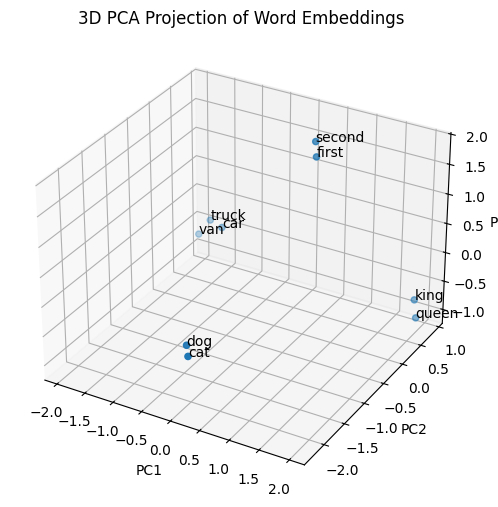

In [26]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

def plot_3d(words, model):
    vectors = []
    valid_words = []

    #get embeddings
    for word in words:
        if word in model.key_to_index:
            vectors.append(model[word])
            valid_words.append(word)
        else:
            print(f"{word} is OOV")

    vectors = np.array(vectors)

    #use PCA for dim-reduction (to 3D)
    pca = PCA(n_components=3)
    reduced = pca.fit_transform(vectors)

    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(reduced[:,0], reduced[:,1], reduced[:,2])

    for i, word in enumerate(valid_words):
        ax.text(reduced[i,0], reduced[i,1], reduced[i,2], word)

    ax.set_title("3D PCA Projection of Word Embeddings")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    plt.show()

words = ["cat", "dog", "car", "truck", "van", "first", "second", "king", "queen"]
plot_3d(words, word_vectors)

#### Define a custom dissimilarity score that goes beyond cosine similarity.

In [32]:
def dist_sim(model, word_1, word_2):
    if word_1 not in model.key_to_index:
        return None
    if word_2 not in model.key_to_index:
        return None
    vec_1 = model[word_1]
    vec_2 = model[word_2]

    return np.linalg.norm(vec_1 - vec_2)

#### Either design your own metric or cite an existing one from literature (provide a proper reference). Explain why your metric captures novelty/diversity better than cosine similarity alone.

Reference: Kulesza, Alex, and Ben Taskar. "Determinantal point processes for machine learning." Foundations and Trends® in Machine Learning 5.2-3 (2012): 123-286.
https://arxiv.org/abs/1207.6083

This captures more than cosine similarity as we construct similarity kernels for each vector in the space, each kernel is collected into a matrix which we take the determinant of. the determinant is a representation of how similar words are in the word set. Smaller determinant means higher similarity, and larger means less similar.

In [28]:
def dpp_diversity(model, word_1, word_2):

    if word_1 not in model.key_to_index:
        return None
    if word_2 not in model.key_to_index:
        return None

    vec_1 = model[word_1]
    vec_2 = model[word_2]

    vectors = [vec_1, vec_2]

    #normalize vectors
    vectors = np.array([
        v / np.linalg.norm(v) for v in vectors
    ])

    #construct similarity kernel
    L = np.dot(vectors, vectors.T)

    #compute determinant
    diversity_score = np.linalg.det(L)

    return diversity_score

In [29]:
def measure_rank_sim(model, word, sim_list, metric=0):
    sims = []

    # cosine similarity
    if metric == 0:
        sim_func = cos_similarity
    # distance similarity
    elif metric == 1:
        sim_func = dist_sim
    # dpp diversity similarity
    elif metric == 2:
        sim_func = dpp_diversity

    for wd in sim_list:
        similarity = sim_func(model, word, wd)
        sims.append((word, wd, similarity))

    return sims


In [52]:
base_word = "cat"
compare_words = ["dog", "car", "truck", "van", "first", "second", "king", "queen"]
words = ["cat", "dog", "car", "truck", "van", "first", "second", "king", "queen"]

In [53]:
pairs = measure_rank_sim(word_vectors, base_word, compare_words, 0)
sorted_pairs = sorted(pairs, key=lambda x: x[2])

for w1, w2, score in sorted_pairs:
    print(f"{w1} - {w2}: {score:.4f}")

cat - second: 0.0519
cat - first: 0.0781
cat - king: 0.1216
cat - queen: 0.1469
cat - van: 0.1751
cat - truck: 0.1809
cat - car: 0.2153
cat - dog: 0.7609


In [54]:
pairs = measure_rank_sim(word_vectors, base_word, compare_words, 1)
sorted_pairs = sorted(pairs, key=lambda x: x[2])

for w1, w2, score in sorted_pairs:
    print(f"{w1} - {w2}: {score:.4f}")

cat - dog: 2.0815
cat - first: 3.4024
cat - second: 3.5369
cat - car: 3.5739
cat - truck: 3.8085
cat - king: 3.9378
cat - queen: 3.9617
cat - van: 3.9906


In [55]:
pairs = measure_rank_sim(word_vectors, base_word, compare_words, 2)
sorted_pairs = sorted(pairs, key=lambda x: x[2])

for w1, w2, score in sorted_pairs:
    print(f"{w1} - {w2}: {score:.4f}")

cat - dog: 0.4210
cat - car: 0.9537
cat - truck: 0.9673
cat - van: 0.9693
cat - queen: 0.9784
cat - king: 0.9852
cat - first: 0.9939
cat - second: 0.9973


In [56]:
import seaborn as sns
def pairwise_matrix_heatmap(model, words, metric=0):
    # cosine similarity
    if metric == 0:
        sim_func = cos_similarity
    # distance similarity
    elif metric == 1:
        sim_func = dist_sim
    # dpp diversity similarity
    elif metric == 2:
        sim_func = dpp_diversity

    n = len(words)
    matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            matrix[i, j] = sim_func(model, words[i], words[j])

    plt.figure(figsize=(8,6))

    sns.heatmap(
        matrix,
        xticklabels=words,
        yticklabels=words,
        annot=True,
        cmap="coolwarm"
    )

    plt.title("Pairwise Comparison Heatmap")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

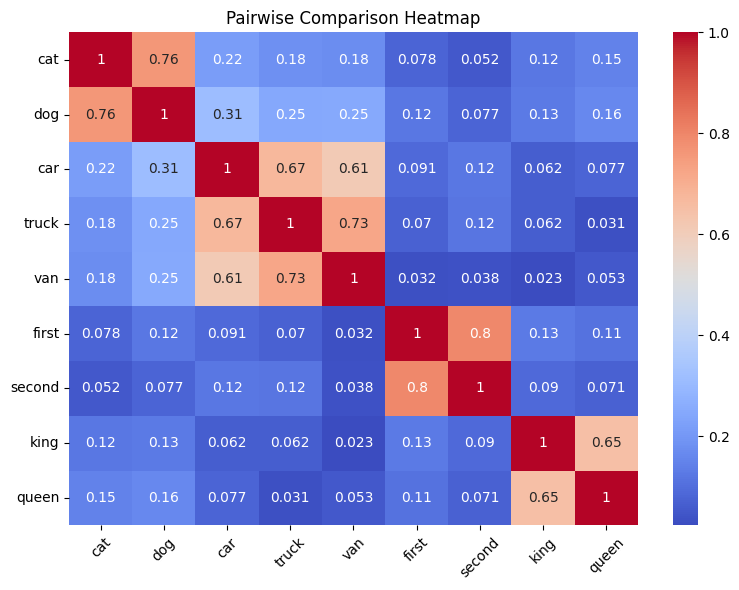

In [57]:
pairwise_matrix_heatmap(word_vectors, words, 0)

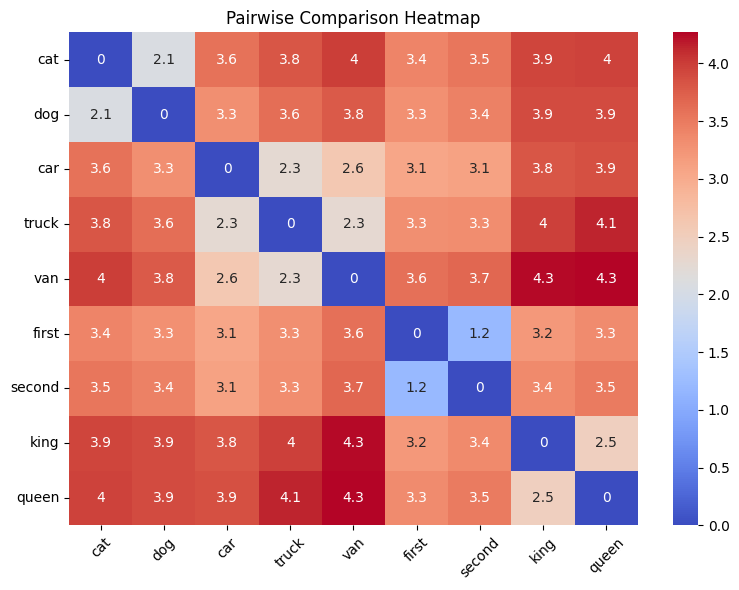

In [58]:
pairwise_matrix_heatmap(word_vectors, words, 1)

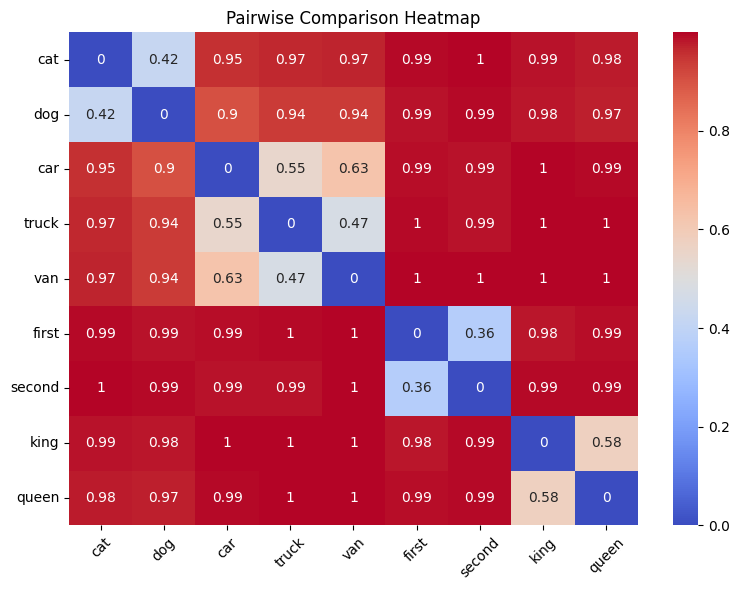

In [59]:
pairwise_matrix_heatmap(word_vectors, words, 2)